# Exploratory Data Analysis – NHANES Oral Health

This notebook generates EDA figures saved to `../figures/`. Data source: `nhanes_model_ready_revise.csv` (5 265 U.S. adults, 2017-2018 NHANES cycle).

In [2]:
import warnings
warnings.filterwarnings('ignore')

import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# set style and figure defaults
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 150, 'savefig.dpi': 150,
                     'figure.facecolor': 'white', 'axes.facecolor': 'white'})
PALETTE = sns.color_palette('muted')

# path management
NOTEBOOK_DIR = os.path.dirname(os.path.abspath('__file__'))
PROJECT_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, '..'))
DATA_PATH = os.path.join(PROJECT_ROOT, 'data', 'processed', 'nhanes_model_ready_revise.csv')
FIG_DIR   = os.path.join(PROJECT_ROOT, 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

def savefig(name):
    path = os.path.join(FIG_DIR, name)
    plt.savefig(path, bbox_inches='tight')
    print(f'Saved → {path}')

print('Setup complete. Figures will be saved to:', FIG_DIR)

Setup complete. Figures will be saved to: /Users/brycegrover/Desktop/DSAN/SPRING_2026/StatLearning-5300/Project/figures


In [3]:
df = pd.read_csv(DATA_PATH, low_memory=False)
print(f'Shape: {df.shape}')
print(f'\nTarget summary:')
print(f'target_poor_selfrated pos rate: {df["target_poor_selfrated"].mean():.1%}')
print(f'target_needs_care pos rate: {df["target_needs_care"].mean():.1%}')
print(f'dmft_score mean: {df["dmft_score"].mean():.2f}, std: {df["dmft_score"].std():.2f}')

Shape: (5265, 137)

Target summary:
target_poor_selfrated pos rate: 34.4%
target_needs_care pos rate: 42.5%
dmft_score mean: 10.74, std: 8.42


## 1. Target Variable Distributions

Saved → /Users/brycegrover/Desktop/DSAN/SPRING_2026/StatLearning-5300/Project/figures/fig01_target_distributions.png


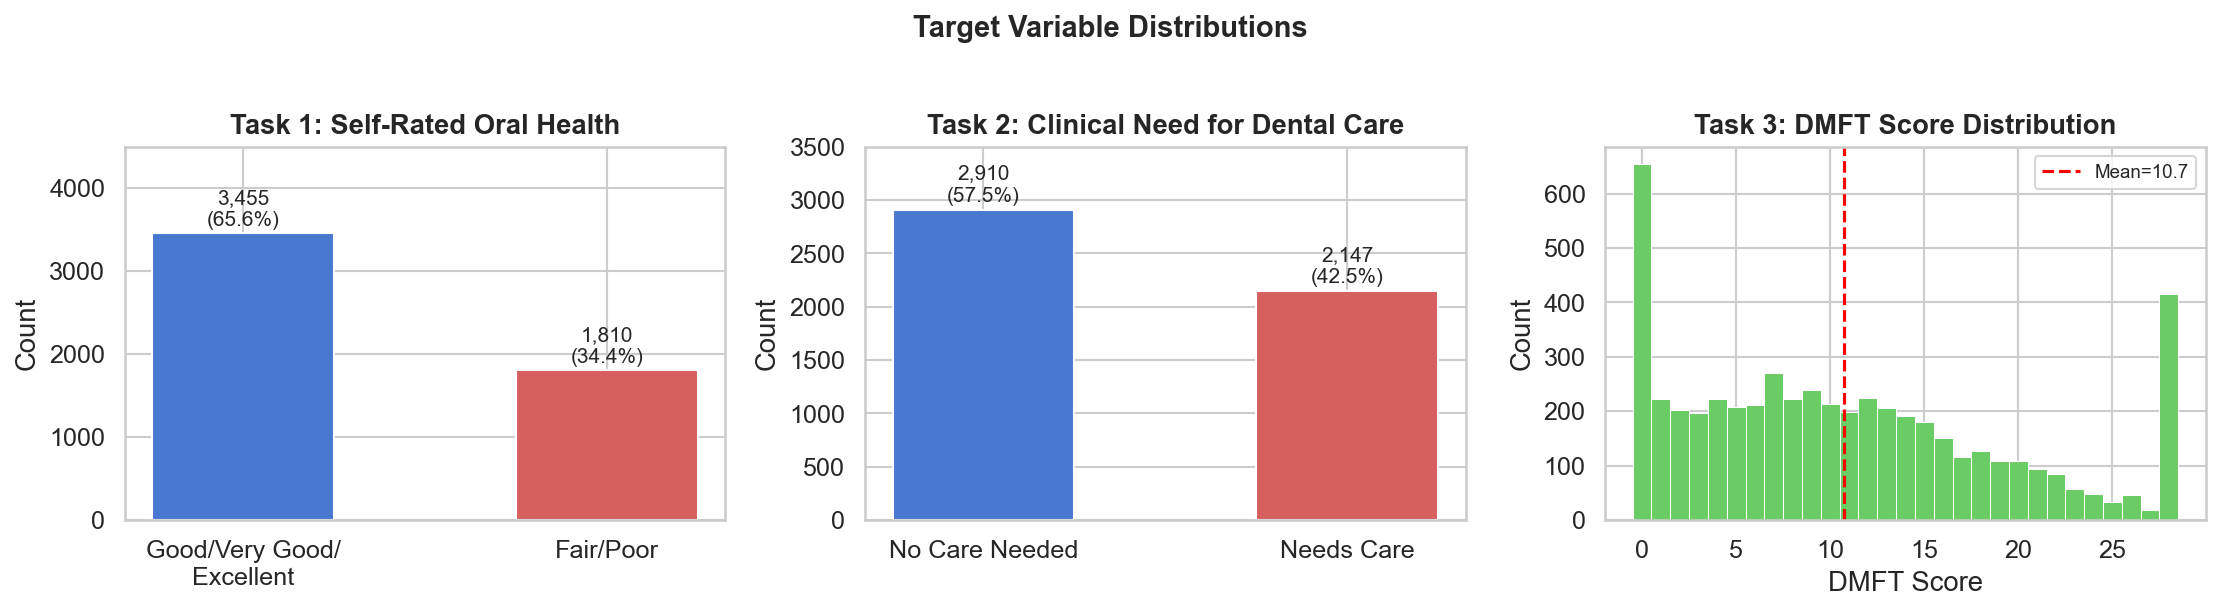

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# taSk1: self rated oral health
ax = axes[0]  # Use the first subplot
counts1 = df['target_poor_selfrated'].value_counts()  # Count class frequencies for the binary target

# Draw a two-bar chart for the self-rated oral health categories
bars1 = ax.bar(
    ['Good/Very Good/\nExcellent', 'Fair/Poor'],
    [counts1.get(0, 0), counts1.get(1, 0)],  # Safely handle missing classes
    color=[PALETTE[0], PALETTE[3]],
    width=0.5,
    edgecolor='white'
)

# count and percentage labels above each bar
for bar, n in zip(bars1, [counts1.get(0, 0), counts1.get(1, 0)]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 40,  # Slight vertical offset above the bar
        f'{n:,}\n({n/len(df):.1%})',
        ha='center',
        va='bottom',
        fontsize=10
    )

ax.set_title('Task 1: Self-Rated Oral Health', fontweight='bold')
ax.set_ylabel('Count')
ax.set_ylim(0, 4500)  # Fix y-axis limit for consistent visual scaling

# task2: clinical need for care 
ax = axes[1]  # Use the second subplot
t2 = df['target_needs_care'].dropna()  # Exclude missing labels before counting
counts2 = t2.value_counts()  # Count class frequencies for the care-need target

# two-bar chart for whether clinical dental care is needed
bars2 = ax.bar(
    ['No Care Needed', 'Needs Care'],
    [counts2.get(0, 0), counts2.get(1, 0)],  # Safely handle missing classes
    color=[PALETTE[0], PALETTE[3]],
    width=0.5,
    edgecolor='white'
)

# count and percentage labels above each bar
for bar, n in zip(bars2, [counts2.get(0, 0), counts2.get(1, 0)]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 40,
        f'{n:,}\n({n/len(t2):.1%})',  # Percent is based only on non-missing rows
        ha='center',
        va='bottom',
        fontsize=10
    )

ax.set_title('Task 2: Clinical Need for Dental Care', fontweight='bold')
ax.set_ylabel('Count')
ax.set_ylim(0, 3500)

# — Task 3: DMFT score ——————————————————————————————————————————
ax = axes[2]  # Use the third subplot

# Plot the distribution of DMFT scores as a histogram
ax.hist(
    df['dmft_score'].dropna(),
    bins=29,
    range=(-0.5, 28.5),  # Center integer-valued scores within bins
    color=PALETTE[2],
    edgecolor='white',
    linewidth=0.5
)

# average DMFT score with a dashed vertical reference line
ax.axvline(
    df['dmft_score'].mean(),
    color='red',
    lw=1.5,
    ls='--',
    label=f'Mean={df["dmft_score"].mean():.1f}'
)

ax.set_title('Task 3: DMFT Score Distribution', fontweight='bold')
ax.set_xlabel('DMFT Score')
ax.set_ylabel('Count')
ax.legend(fontsize=9)

plt.suptitle('Target Variable Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

savefig('fig01_target_distributions.png')
plt.show()

## 2. DMFT Score – Bimodal Distribution Detail

Saved → /Users/brycegrover/Desktop/DSAN/SPRING_2026/StatLearning-5300/Project/figures/fig02_dmft_distribution.png


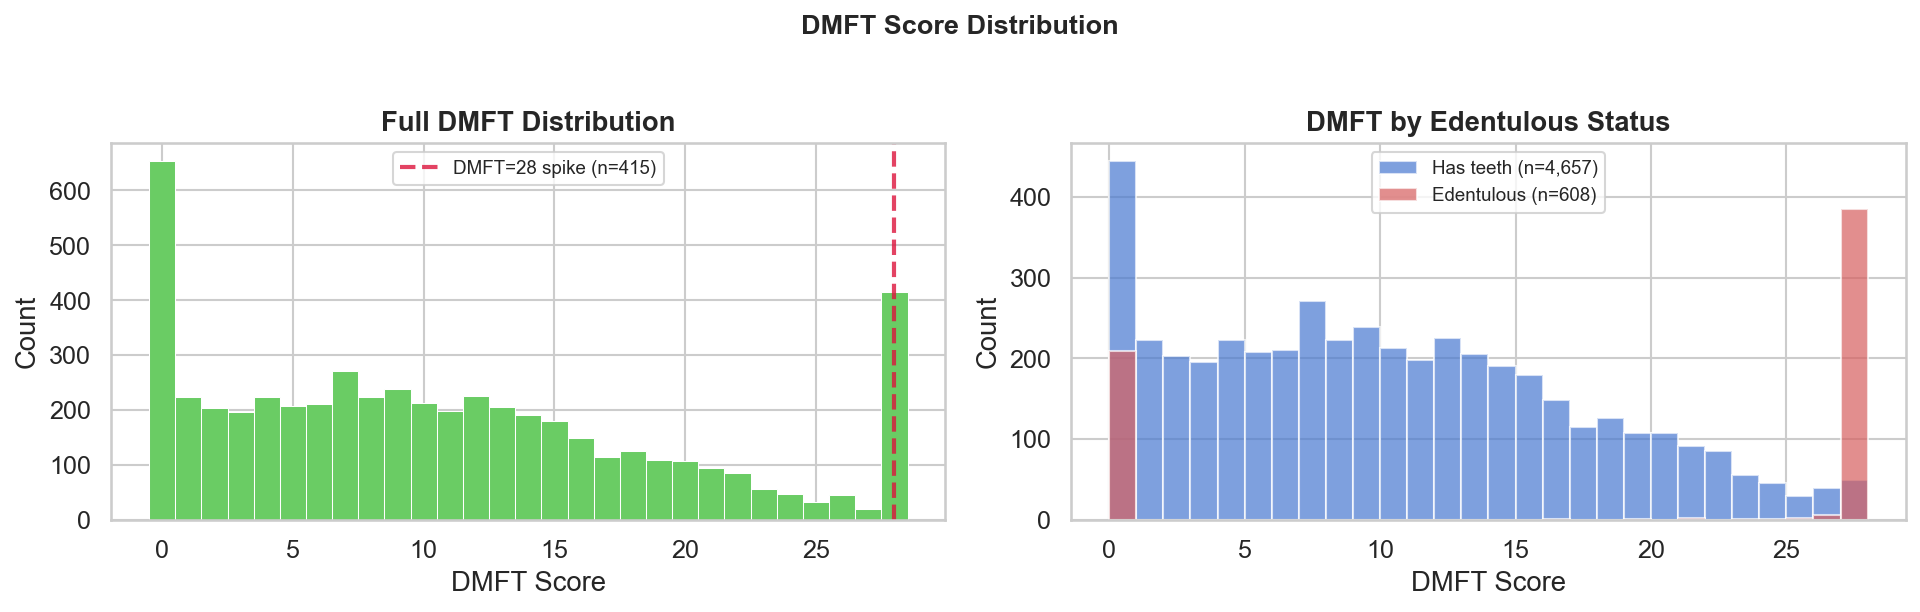

In [5]:
dmft = df['dmft_score'].dropna()
eden_dmft = df.loc[df['is_edentulous']==1, 'dmft_score'].dropna()
neden_dmft = df.loc[df['is_edentulous']==0, 'dmft_score'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# see full distribution
ax = axes[0]
ax.hist(dmft, bins=29, range=(-0.5, 28.5),
        color=PALETTE[2], edgecolor='white', linewidth=0.5)
ax.axvline(28, color='crimson', lw=2, ls='--', alpha=0.8,
           label=f'DMFT=28 spike (n={int((dmft==28).sum())})')
ax.set_xlabel('DMFT Score'); ax.set_ylabel('Count')
ax.set_title('Full DMFT Distribution', fontweight='bold')
ax.legend(fontsize=9)

# edentulous vs non-edentulous
ax = axes[1]
ax.hist(neden_dmft, bins=28, range=(0, 28), alpha=0.7,
        color=PALETTE[0], edgecolor='white', label=f'Has teeth (n={len(neden_dmft):,})')
ax.hist(eden_dmft, bins=28, range=(0, 28), alpha=0.7,
        color=PALETTE[3], edgecolor='white', label=f'Edentulous (n={len(eden_dmft):,})')
ax.set_xlabel('DMFT Score'); ax.set_ylabel('Count')
ax.set_title('DMFT by Edentulous Status', fontweight='bold')
ax.legend(fontsize=9)

plt.suptitle('DMFT Score Distribution', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
savefig('fig02_dmft_distribution.png')
plt.show()

## 3. Demographic Features

Saved → /Users/brycegrover/Desktop/DSAN/SPRING_2026/StatLearning-5300/Project/figures/fig03_demographics.png


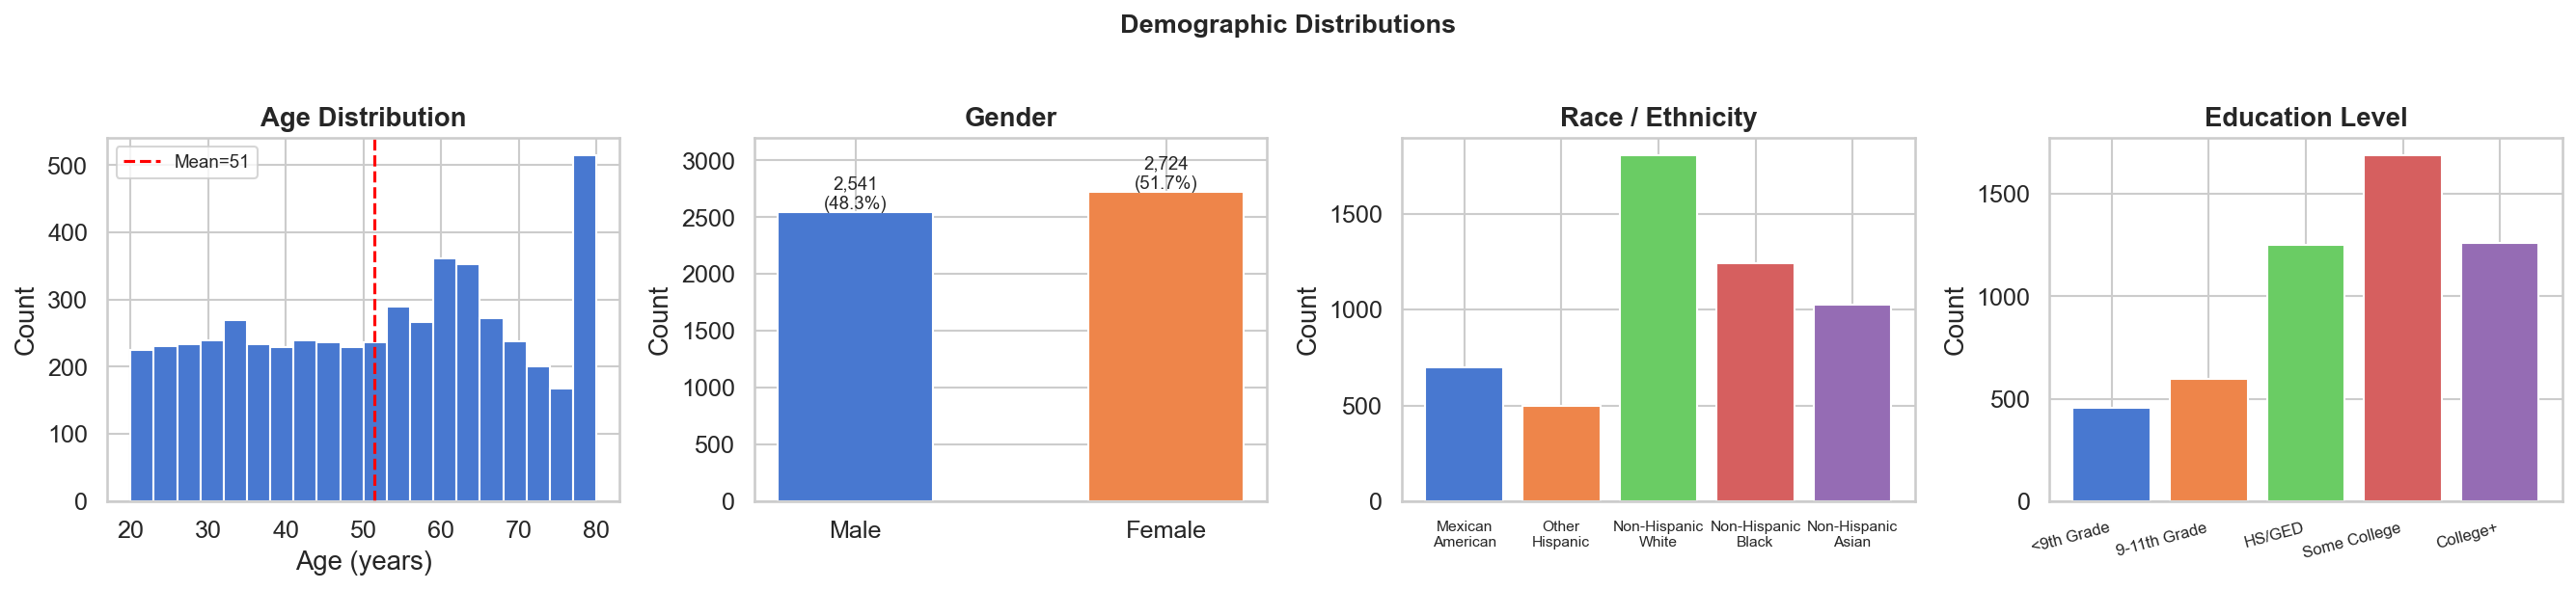

In [6]:
# readable labels for race/ethnicity categories to be used on the x-axis. From NHANES codebook: https://wwwn.cdc.gov/Nchs/Nhanes/2017-2018/DEMO_J.htm#RACEETH
race_labels = {
    1: 'Mexican\nAmerican',
    2: 'Other\nHispanic',
    3: 'Non-Hispanic\nWhite',
    4: 'Non-Hispanic\nBlack',
    5: 'Non-Hispanic\nAsian',
    7: 'Other/\nMultiracial'
}

# Readable labels for coded adult education categories from NHANES codebook: https://wwwn.cdc.gov/Nchs/Nhanes/2017-2018/DEMO_J.htm#EDUCA
edu_labels = {
    1: '<9th Grade',
    2: '9-11th Grade',
    3: 'HS/GED',
    4: 'Some College',
    5: 'College+'
}

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

# subplot for age distribution
ax = axes[0]

# plot age as a histogram after excluding missing values
ax.hist(df['age'].dropna(), bins=20, color=PALETTE[0], edgecolor='white')

# vertical dashed line at the sample mean age
ax.axvline(
    df['age'].mean(),
    color='red',
    ls='--',
    lw=1.5,
    label=f'Mean={df["age"].mean():.0f}'
)

ax.set_xlabel('Age (years)')
ax.set_ylabel('Count')
ax.set_title('Age Distribution', fontweight='bold')
ax.legend(fontsize=9)

# second subplot for gender counts
ax = axes[1] 
gc = df['gender'].value_counts()

# two-bar chart for male and female counts
ax.bar(
    ['Male', 'Female'],
    [gc.get(1, 0), gc.get(2, 0)], # handle potential missing categories
    color=[PALETTE[0], PALETTE[1]],
    edgecolor='white',
    width=0.5
)

# count and percentage labels above each gender bar
for i, (label, key) in enumerate([('Male', 1), ('Female', 2)]):
    n = gc.get(key, 0)
    ax.text(i, n + 30, f'{n:,}\n({n/len(df):.1%})', ha='center', fontsize=9)

ax.set_ylabel('Count')
ax.set_title('Gender', fontweight='bold')
ax.set_ylim(0, 3200)  # adjust y-axis limit to leave room for labs

# third subplot for race distribution
ax = axes[2]
rc = df['race_ethnicity'].value_counts().sort_index()  # categories in order
labels_r = [race_labels.get(k, str(k)) for k in rc.index] # display labels for x-axis

# bar chart for race
bars = ax.bar(
    range(len(rc)),
    rc.values,
    color=PALETTE[:len(rc)],
    edgecolor='white'
)

# custom category labels to the x-axis
ax.set_xticks(range(len(rc)))
ax.set_xticklabels(labels_r, fontsize=7.5)
ax.set_ylabel('Count')
ax.set_title('Race / Ethnicity', fontweight='bold')

# fourth subplot for education distribution
ax = axes[3]
ec = df['education_adult'].value_counts().sort_index()  
labels_e = [edu_labels.get(k, str(k)) for k in ec.index]
ax.bar(
    range(len(ec)),
    ec.values,
    color=PALETTE[:len(ec)],
    edgecolor='white'
)

# neeed to rotate the labels slightly so longer education names fit
ax.set_xticks(range(len(ec)))
ax.set_xticklabels(labels_e, fontsize=8, rotation=15, ha='right')
ax.set_ylabel('Count')
ax.set_title('Education Level', fontweight='bold')

plt.suptitle('Demographic Distributions', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()

savefig('fig03_demographics.png')
plt.show()

## 4. SES Features – Income & Education by Oral Health

Saved → /Users/brycegrover/Desktop/DSAN/SPRING_2026/StatLearning-5300/Project/figures/fig04_ses_features.png


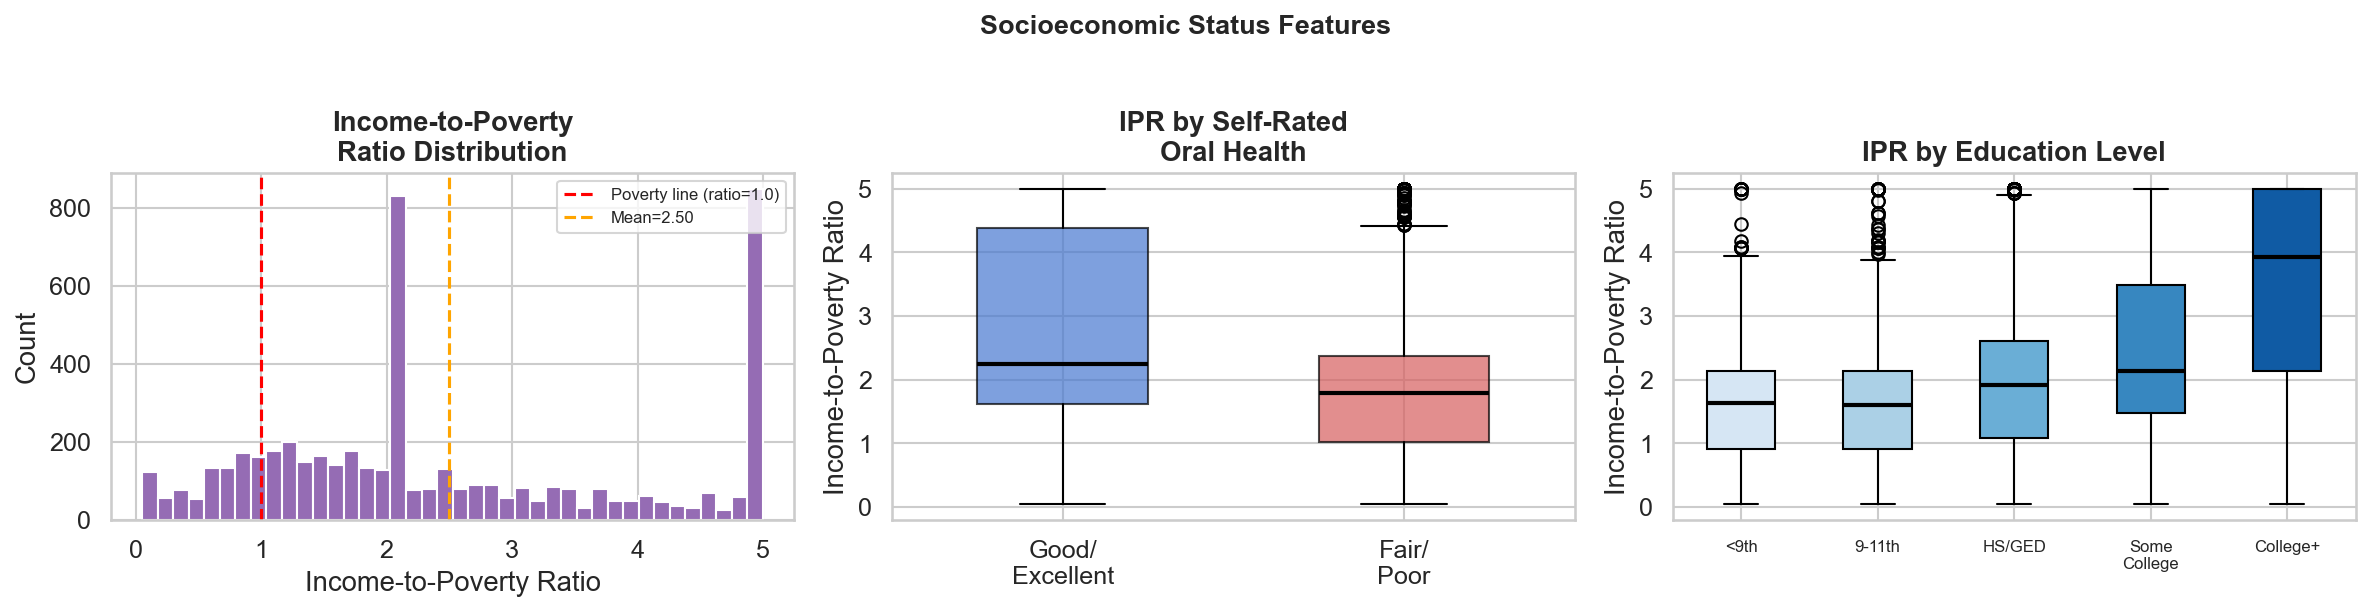

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# income poverty ratio distribution
ax = axes[0]
ipr = df['income_poverty_ratio'].dropna()

# histogram of ipr values
ax.hist(ipr, bins=40, color=PALETTE[4], edgecolor='white')

# poverty threshold and sample mean reference lines
ax.axvline(1.0, color='red', ls='--', lw=1.5, label='Poverty line (ratio=1.0)')
ax.axvline(
    ipr.mean(),
    color='orange',
    ls='--',
    lw=1.5,
    label=f'Mean={ipr.mean():.2f}'
)

ax.set_xlabel('Income-to-Poverty Ratio')
ax.set_ylabel('Count')
ax.set_title('Income-to-Poverty\nRatio Distribution', fontweight='bold')
ax.legend(fontsize=8)

# ipr by self-rated oral health
ax = axes[1]

# split into good vs poor self-rated oral health groups
d_good = df.loc[df['target_poor_selfrated'] == 0, 'income_poverty_ratio'].dropna()
d_poor = df.loc[df['target_poor_selfrated'] == 1, 'income_poverty_ratio'].dropna()

# side by side boxplots to compare the distributions
bp = ax.boxplot(
    [d_good, d_poor],
    patch_artist=True,
    widths=0.5,
    labels=['Good/\nExcellent', 'Fair/\nPoor'],
    medianprops=dict(color='black', lw=2)
)

# Fboxplots with the same colors used for the self-rated oral health bars in the previous figure
for patch, color in zip(bp['boxes'], [PALETTE[0], PALETTE[3]]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('Income-to-Poverty Ratio')
ax.set_title('IPR by Self-Rated\nOral Health', fontweight='bold')

# ipr by education level
ax = axes[2]

# shorten teh education labels so they fit better on the x-axis
edu_labels_short = {
    1: '<9th',
    2: '9-11th',
    3: 'HS/GED',
    4: 'Some\nCollege',
    5: 'College+'
}

# make the list of ipr values for each education category
edu_groups = [
    df.loc[df['education_adult'] == k, 'income_poverty_ratio'].dropna()
    for k in sorted(df['education_adult'].dropna().unique())
]

# matching x-axis labels for the observed education categories
edu_lbls = [
    edu_labels_short.get(k, str(k))
    for k in sorted(df['education_adult'].dropna().unique())
]

# boxplots of ipr by education level with the shortened labels
bp2 = ax.boxplot(
    edu_groups,
    patch_artist=True,
    widths=0.5,
    labels=edu_lbls,
    medianprops=dict(color='black', lw=2)
)

colors = sns.color_palette('Blues', len(edu_groups))
for patch, color in zip(bp2['boxes'], colors):
    patch.set_facecolor(color)

ax.set_ylabel('Income-to-Poverty Ratio')
ax.set_title('IPR by Education Level', fontweight='bold')
ax.set_xticklabels(edu_lbls, fontsize=8)

plt.suptitle('Socioeconomic Status Features', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
savefig('fig04_ses_features.png')
plt.show()

## 5. Access to Care Features

Saved → /Users/brycegrover/Desktop/DSAN/SPRING_2026/StatLearning-5300/Project/figures/fig05_access_to_care.png


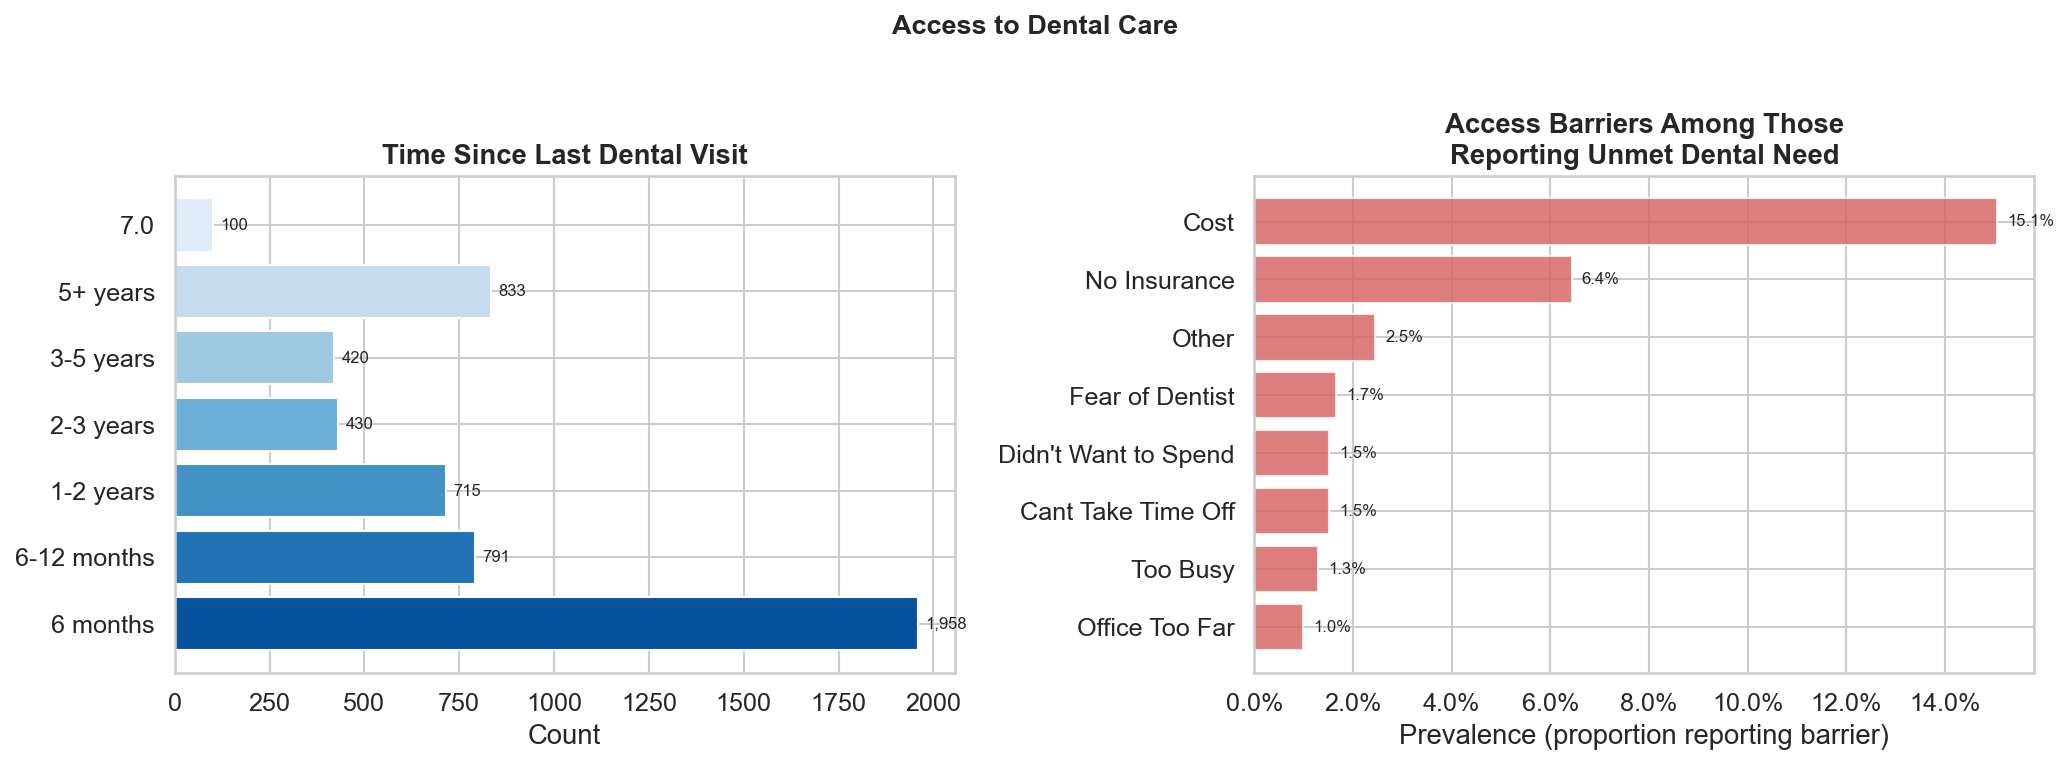

In [ ]:
# cols for the access barriers for those with unmet dental need
barrier_cols = [
    'barrier_cost', 'barrier_insurance_no_coverage',
    'barrier_cant_take_time_off_work', 'barrier_too_busy',
    'barrier_office_too_far', 'barrier_afraid_of_dentist',
    'barrier_didnt_want_to_spend', 'barrier_other',
]

# display labs
barrier_labels = ['Cost', 'No Insurance', 'Cant Take Time Off',
                  'Too Busy', 'Office Too Far', 'Fear of Dentist',
                  "Didn't Want to Spend", 'Other']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# last dental visit breakdown
ax = axes[0]

# map coded visit-timing values to readable category labels from NHANES codebook: https://wwwn.cdc.gov/Nchs/Nhanes/2017-2018/DEMO_J.htm#DMDYRS
ldv_labels = {1:'6 months', 2:'6-12 months', 3:'1-2 years',
              4:'2-3 years', 5:'3-5 years', 6:'5+ years', 8:'Never'}

# count the frequencies of each last dental visit category
# sort by the coded category order
# get display labels for the x-axis
ldvc = df['last_dental_visit'].value_counts().sort_index()
# convert codes to display labels
lbl  = [ldv_labels.get(k, str(k)) for k in ldvc.index]

# horizontal bar chart of time since last dental visit
bars = ax.barh(range(len(lbl)), ldvc.values,
               color=sns.color_palette('Blues_r', len(lbl)), edgecolor='white')

# custom category labels to the y-axis
ax.set_yticks(range(len(lbl)))
ax.set_yticklabels(lbl)
ax.set_xlabel('Count')
ax.set_title('Time Since Last Dental Visit', fontweight='bold')

# labs with counts at the end of each bar
for bar, n in zip(bars, ldvc.values):
    ax.text(bar.get_width()+20, bar.get_y()+bar.get_height()/2,
            f'{n:,}', va='center', fontsize=8)

# barrier prevalence
ax = axes[1]

# find the proportion of respondents reporting each barrier among those with unmet dental need
barrier_rates = [(df[c]==1).mean() for c in barrier_cols]

# sort barriers from least to most prevalent
order = sorted(range(len(barrier_rates)), key=lambda i: barrier_rates[i])

# plot a horizontal bar chart of barrier prevalence
bars2 = ax.barh([barrier_labels[i] for i in order],
                [barrier_rates[i] for i in order],
                color=PALETTE[3], edgecolor='white', alpha=0.8)

ax.set_xlabel('Prevalence (proportion reporting barrier)')
ax.set_title('Access Barriers Among Those\nReporting Unmet Dental Need', fontweight='bold')

# format the x-axis to show percentages instead of proportions
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

# add percentage labels to the end of each barrier bar
for bar, rate in zip(bars2, [barrier_rates[i] for i in order]):
    ax.text(rate+0.002, bar.get_y()+bar.get_height()/2,
            f'{rate:.1%}', va='center', fontsize=8)

plt.suptitle('Access to Dental Care', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
savefig('fig05_access_to_care.png')
plt.show()

## 6. DMFT by Key Socioeconomic and Demographic Features

Saved → /Users/brycegrover/Desktop/DSAN/SPRING_2026/StatLearning-5300/Project/figures/fig06_dmft_by_features.png


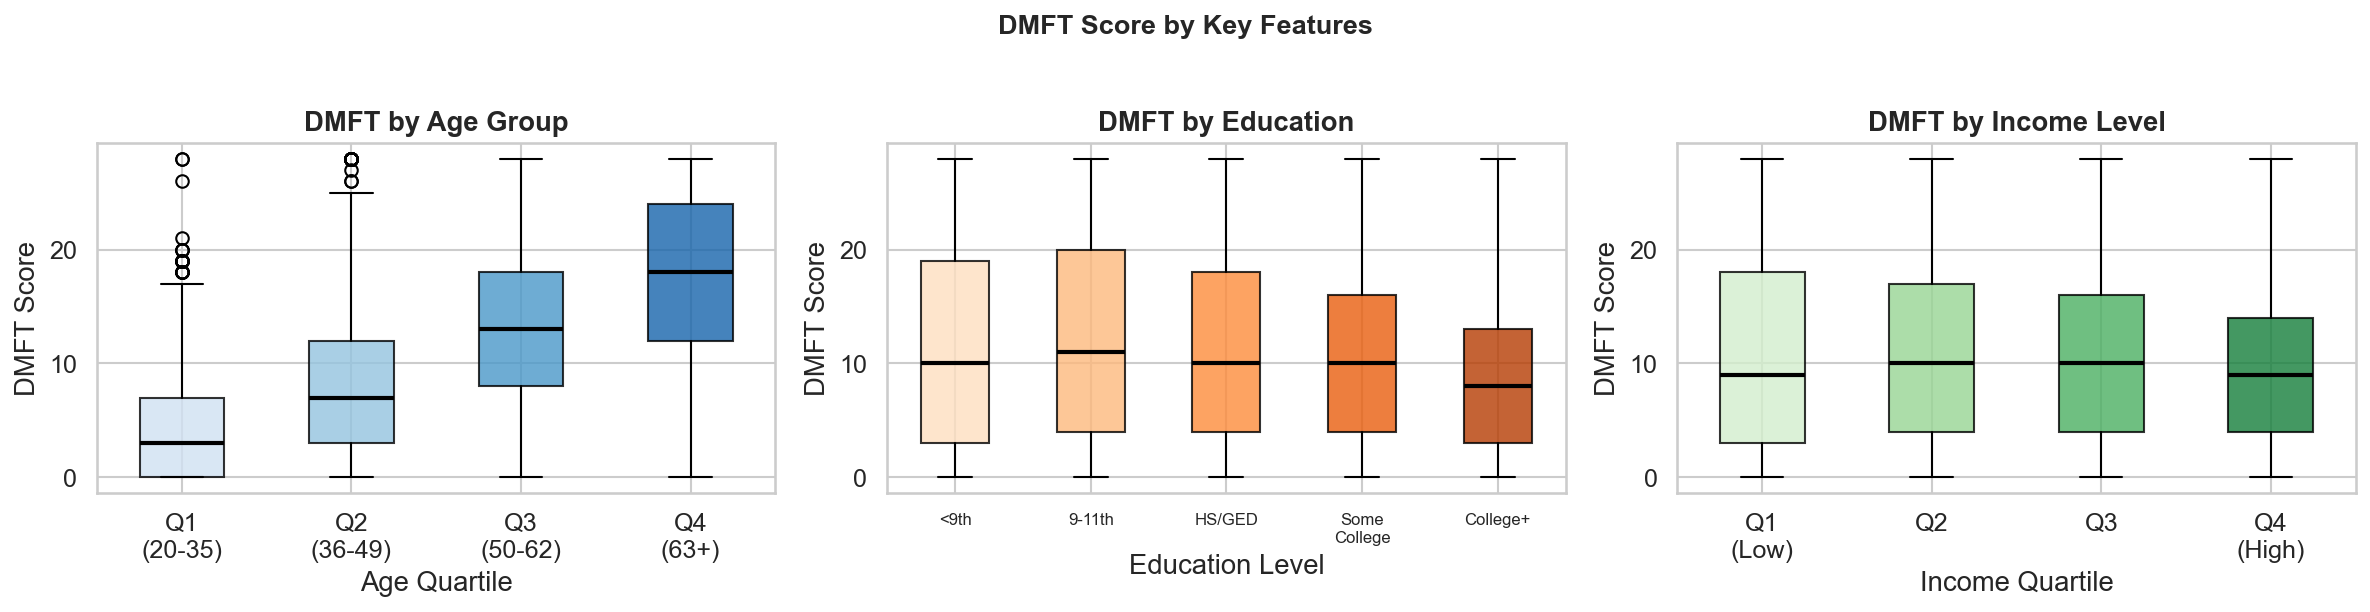

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# DMFT by age quartiles
ax = axes[0]
df['age_quartile'] = pd.qcut(df['age'], 4,
    labels=['Q1\n(20-35)', 'Q2\n(36-49)', 'Q3\n(50-62)', 'Q4\n(63+)'])

# make a list of DMFT scores for each age quartile group
dmft_by_age = [df.loc[df['age_quartile']==q, 'dmft_score'].dropna()
               for q in df['age_quartile'].cat.categories]

# boxplots of DMFT by age quartile with the same blue colors used for the age distribution histogram in the previous figure
bp = ax.boxplot(dmft_by_age, patch_artist=True, widths=0.5,
                labels=df['age_quartile'].cat.categories,
                medianprops=dict(color='black', lw=2))

# color the boxes with the same blues used for the age distribution histogram in the previous figure
for patch, color in zip(bp['boxes'], sns.color_palette('Blues', 4)):
    patch.set_facecolor(color); patch.set_alpha(0.8)
    
ax.set_xlabel('Age Quartile'); ax.set_ylabel('DMFT Score')
ax.set_title('DMFT by Age Group', fontweight='bold')

# DMFT by education
ax = axes[1]

# shorten the education labels so they fit better on the x-axis
edu_labels_short = {1:'<9th', 2:'9-11th', 3:'HS/GED', 4:'Some\nCollege', 5:'College+'}

# keys for the observed education categories, sorted in order
edu_keys = sorted(df['education_adult'].dropna().unique())

# make a list of DMFT scores for each education category
dmft_by_edu = [df.loc[df['education_adult']==k, 'dmft_score'].dropna() for k in edu_keys]

# boxplots of DMFT by education level with the shortened labels
bp2 = ax.boxplot(dmft_by_edu, patch_artist=True, widths=0.5,
                 labels=[edu_labels_short.get(k, str(k)) for k in edu_keys],
                 medianprops=dict(color='black', lw=2))

# color the boxes with the same oranges used for the education level bars in the previous figure
for patch, color in zip(bp2['boxes'], sns.color_palette('Oranges', len(edu_keys))):
    patch.set_facecolor(color); patch.set_alpha(0.8)
    
# set labs
ax.set_xlabel('Education Level'); ax.set_ylabel('DMFT Score')
ax.set_title('DMFT by Education', fontweight='bold')
ax.set_xticklabels([edu_labels_short.get(k, str(k)) for k in edu_keys], fontsize=8)

# DMFT by income quartile
ax = axes[2]

# create an income quartile variable by binning the income poverty ratio into 4 group
# clip the ipr values at 0.05 and 5 to avoid extreme outliers
df['ipr_quartile'] = pd.qcut(df['income_poverty_ratio'].clip(0.05, 5),
    4, labels=['Q1\n(Low)', 'Q2', 'Q3', 'Q4\n(High)'])

# make a list of DMFT scores for each income quartile group
dmft_by_ipr = [df.loc[df['ipr_quartile']==q, 'dmft_score'].dropna()
               for q in df['ipr_quartile'].cat.categories]

# boxplots of DMFT by income quartile
bp3 = ax.boxplot(dmft_by_ipr, patch_artist=True, widths=0.5,
                 labels=df['ipr_quartile'].cat.categories,
                 medianprops=dict(color='black', lw=2))

# color the boxes with the same greens used for the income distribution histogram
for patch, color in zip(bp3['boxes'], sns.color_palette('Greens', 4)):
    patch.set_facecolor(color); patch.set_alpha(0.8)
ax.set_xlabel('Income Quartile'); ax.set_ylabel('DMFT Score')
ax.set_title('DMFT by Income Level', fontweight='bold')

plt.suptitle('DMFT Score by Key Features', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
savefig('fig06_dmft_by_features.png')
plt.show()

## 7. Oral Health Self-Report Distributions

Saved → /Users/brycegrover/Desktop/DSAN/SPRING_2026/StatLearning-5300/Project/figures/fig07_self_report.png


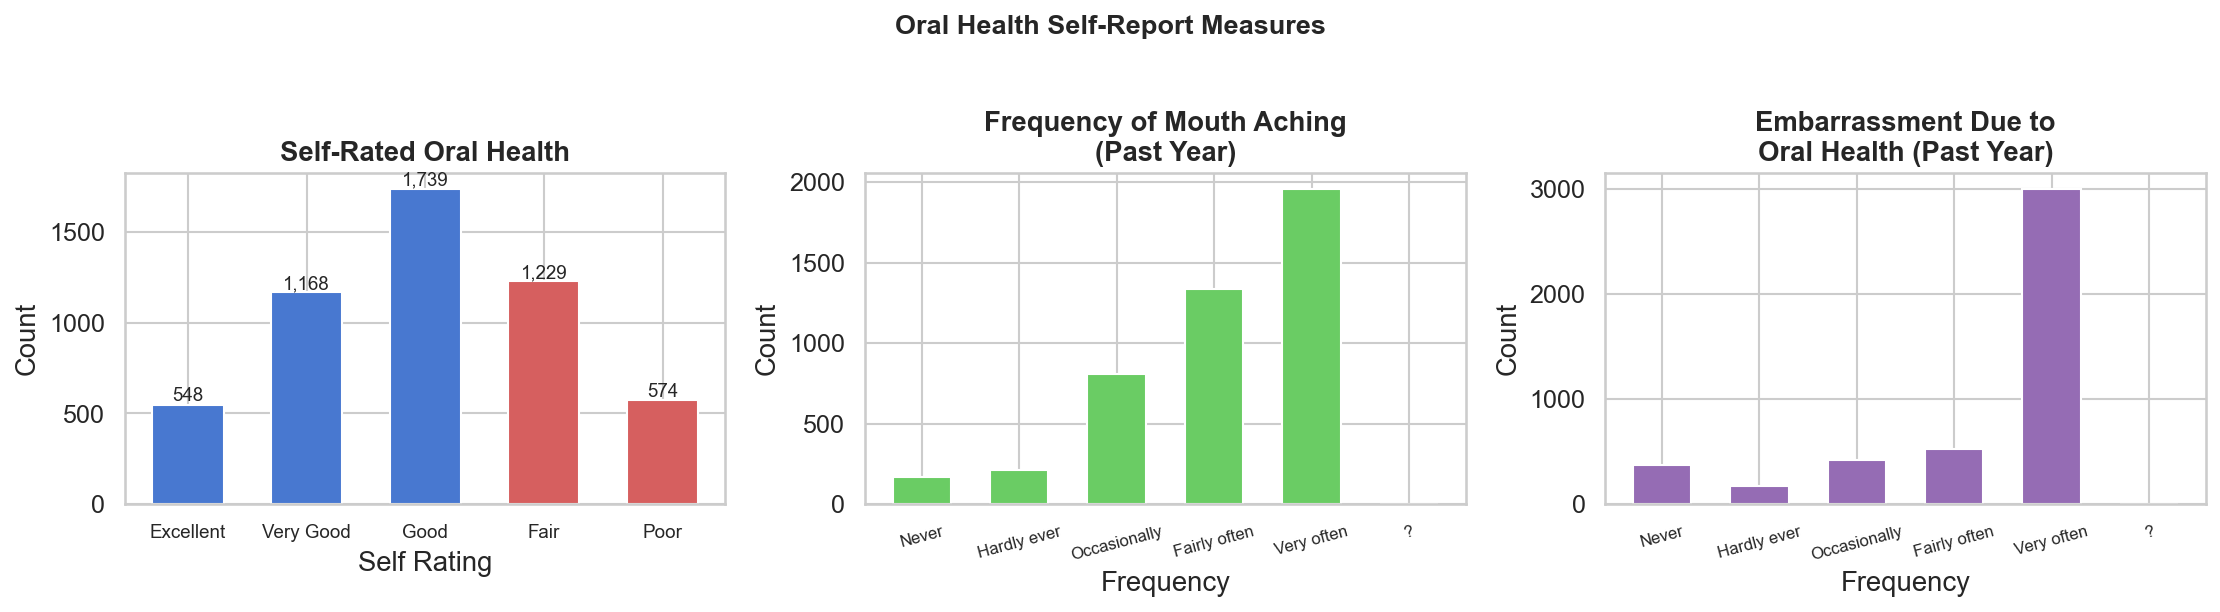

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Self-rated oral health
ax = axes[0]
sroh_labels = {1:'Excellent', 2:'Very Good', 3:'Good', 4:'Fair', 5:'Poor'}

# count the frequencies of each self-rated oral health category, sorted by the coded category order
sroh_c = df['self_rated_oral_health'].value_counts().sort_index()

colors_sroh = [PALETTE[0], PALETTE[0], PALETTE[0], PALETTE[3], PALETTE[3]]

# bar chart for self-rated oral health categories with the specified colors
bars_s = ax.bar([sroh_labels.get(k,'?') for k in sroh_c.index],
                sroh_c.values, color=colors_sroh, edgecolor='white', width=0.6)

# add counts
for bar, n in zip(bars_s, sroh_c.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
            f'{n:,}', ha='center', fontsize=9)

ax.set_xlabel('Self Rating')
ax.set_ylabel('Count')
ax.set_title('Self-Rated Oral Health', fontweight='bold')
ax.tick_params(axis='x', labelsize=9)

# Mouth aching frequency
ax = axes[1]
freq_labels = {1:'Never', 2:'Hardly ever', 3:'Occasionally', 4:'Fairly often', 5:'Very often'}

fc = df['freq_mouth_aching_past_year'].value_counts().sort_index()

# bar chart for frequency of mouth aching in the past year
ax.bar([freq_labels.get(k,'?') for k in fc.index],
       fc.values, color=PALETTE[2], edgecolor='white', width=0.6)

ax.set_xlabel('Frequency')
ax.set_ylabel('Count')
ax.set_title('Frequency of Mouth Aching\n(Past Year)', fontweight='bold')
ax.tick_params(axis='x', labelsize=8, rotation=15)  # Rotate labels to prevent overlap

# embarrassment frequency
ax = axes[2] 

ec = df['freq_embarrassed_from_mouth'].value_counts().sort_index()

ax.bar([freq_labels.get(k,'?') for k in ec.index],
       ec.values, color=PALETTE[4], edgecolor='white', width=0.6)

ax.set_xlabel('Frequency')
ax.set_ylabel('Count')
ax.set_title('Embarrassment Due to\nOral Health (Past Year)', fontweight='bold')
ax.tick_params(axis='x', labelsize=8, rotation=15)  # Rotate labels to improve readability

# Add an overall title, tighten spacing, save, and display the figure
plt.suptitle('Oral Health Self-Report Measures', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
savefig('fig07_self_report.png')
plt.show()

## 8. Missing Data Summary

Saved → /Users/brycegrover/Desktop/DSAN/SPRING_2026/StatLearning-5300/Project/figures/fig08_missing_data.png


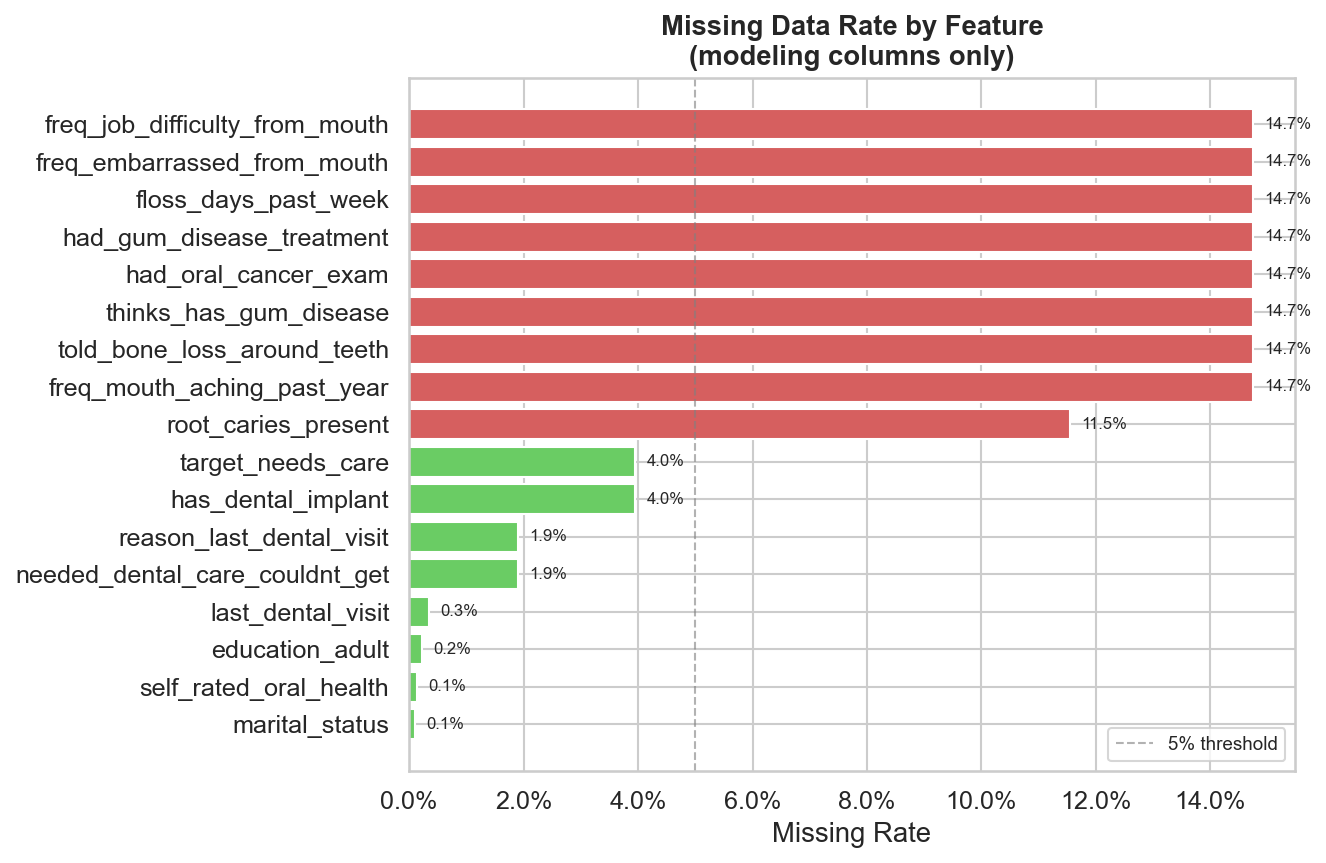

In [ ]:
# variables intended for modeling
# exclude identifiers and raw tooth-level code fields
model_cols = [
    'income_poverty_ratio', 'education_adult', 'age', 'gender', 'race_ethnicity',
    'marital_status', 'household_size', 'country_of_birth',
    'last_dental_visit', 'reason_last_dental_visit', 'needed_dental_care_couldnt_get',
    'barrier_cost', 'barrier_insurance_no_coverage', 'barrier_cant_take_time_off_work',
    'barrier_too_busy', 'barrier_office_too_far', 'barrier_afraid_of_dentist',
    'barrier_didnt_want_to_spend', 'barrier_other',
    'floss_days_past_week', 'had_gum_disease_treatment', 'had_oral_cancer_exam',
    'thinks_has_gum_disease', 'told_bone_loss_around_teeth',
    'freq_mouth_aching_past_year', 'freq_job_difficulty_from_mouth',
    'freq_embarrassed_from_mouth', 'self_rated_oral_health',
    'dmft_score', 'teeth_present', 'teeth_decayed', 'teeth_filled_sound',
    'treatment_ratio', 'is_edentulous', 'root_caries_present', 'has_dental_implant',
    'target_poor_selfrated', 'target_needs_care',
]

# find percentage of missing values in each modeling column, sorted from least to most missing
miss_pct = df[model_cols].isna().mean().sort_values(ascending=True)

# keep only features with at least some missing data
miss_pct = miss_pct[miss_pct > 0]

# scale figure height based on the number of features shown
fig, ax = plt.subplots(figsize=(9, max(4, len(miss_pct) * 0.35)))

# plot horizontal bars
# use a different color for features exceeding 10% missingness
bars = ax.barh(
    miss_pct.index,
    miss_pct.values,
    color=[PALETTE[3] if v > 0.10 else PALETTE[2] for v in miss_pct.values],
    edgecolor='white'
)

# add a reference line at 5% missingness just to visually separate features with low vs moderate missingness
ax.axvline(0.05, color='gray', ls='--', lw=1, alpha=0.6, label='5% threshold')

ax.set_xlabel('Missing Rate')
ax.set_title('Missing Data Rate by Feature\n(modeling columns only)', fontweight='bold')

# pertcentages
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(fontsize=9)

# annotate each bar with its missing data percentage
for bar, v in zip(bars, miss_pct.values):
    ax.text(v + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{v:.1%}', va='center', fontsize=8)

plt.tight_layout()
savefig('fig08_missing_data.png')
plt.show()

## 9. Correlation Heatmap – Key Numeric Features

Saved → /Users/brycegrover/Desktop/DSAN/SPRING_2026/StatLearning-5300/Project/figures/fig09_correlation_heatmap.png


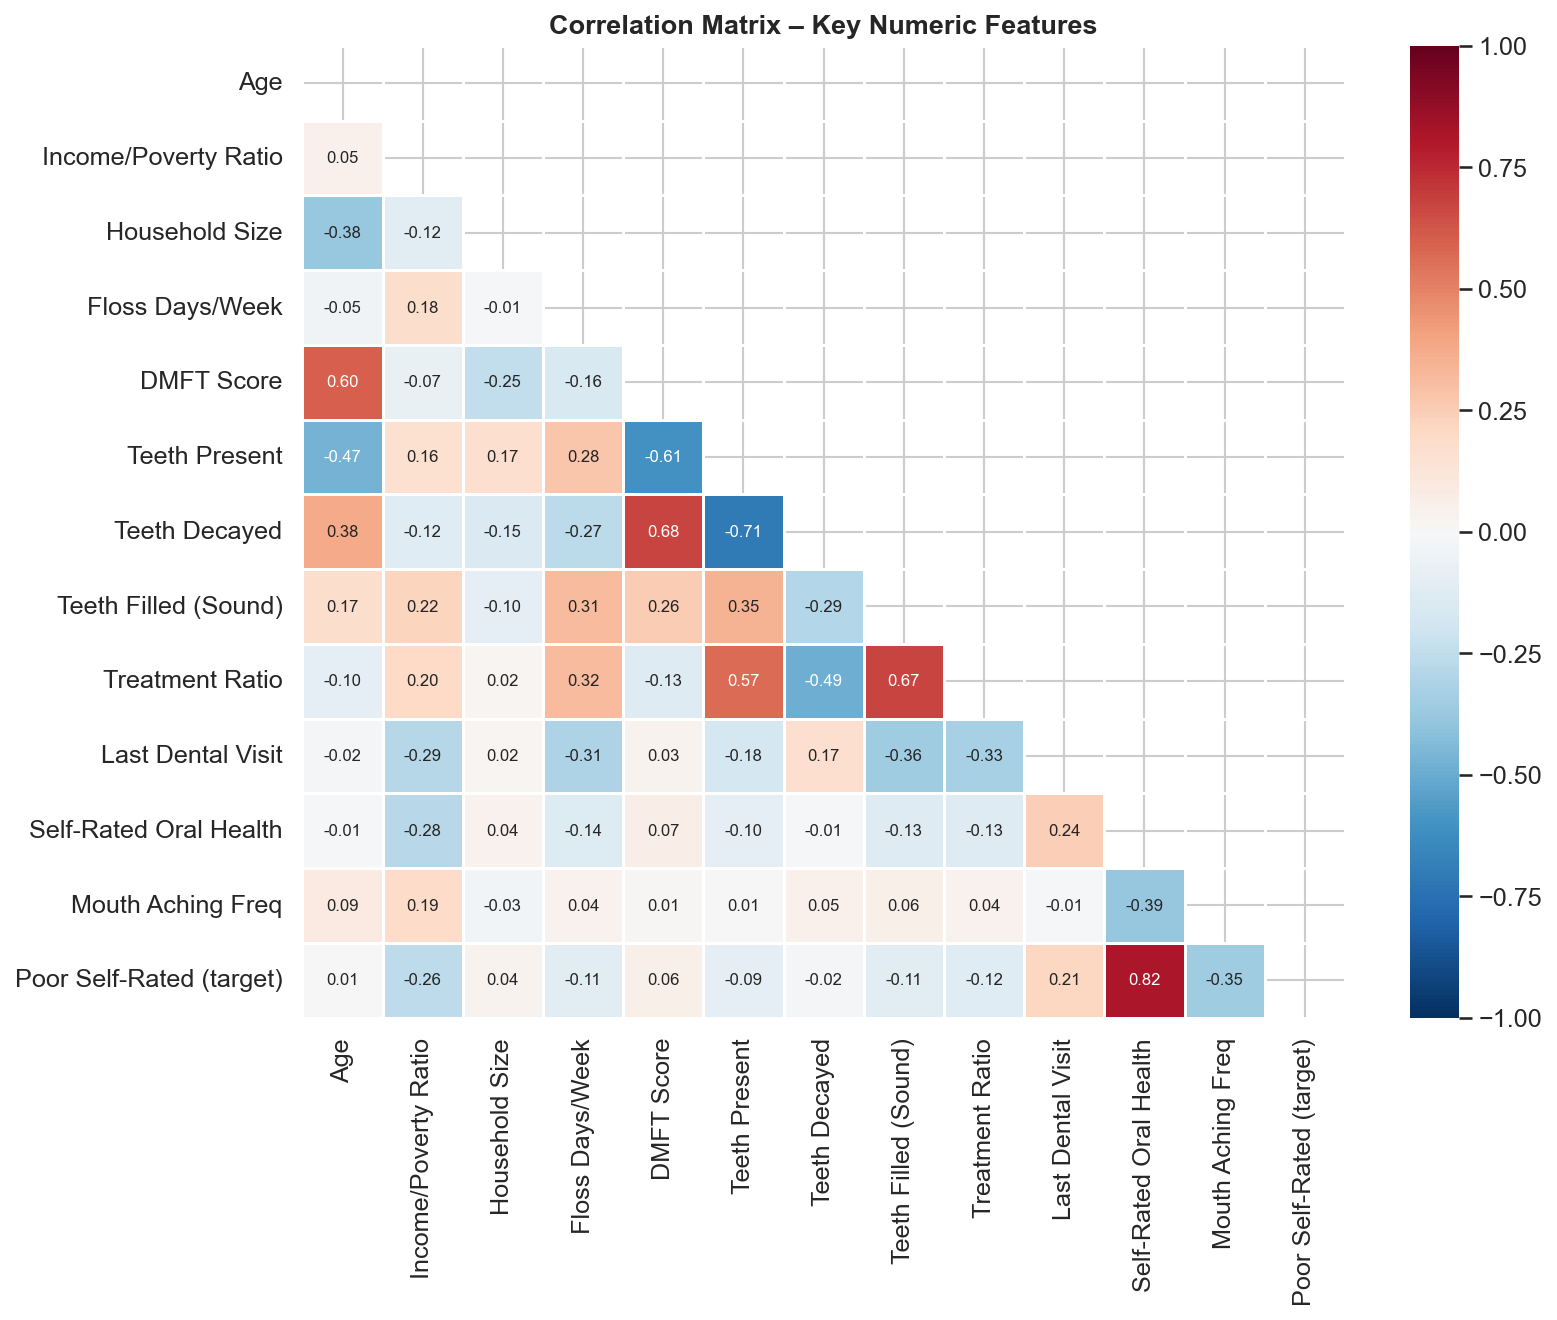

In [ ]:
# numeric columns for correlation analysis
num_cols = [
    'age', 'income_poverty_ratio', 'household_size', 'floss_days_past_week',
    'dmft_score', 'teeth_present', 'teeth_decayed', 'teeth_filled_sound',
    'treatment_ratio', 'last_dental_visit', 'self_rated_oral_health',
    'freq_mouth_aching_past_year', 'target_poor_selfrated',
]

# readable display names for the heatmap axes
num_labels = [
    'Age', 'Income/Poverty Ratio', 'Household Size', 'Floss Days/Week',
    'DMFT Score', 'Teeth Present', 'Teeth Decayed', 'Teeth Filled (Sound)',
    'Treatment Ratio', 'Last Dental Visit', 'Self-Rated Oral Health',
    'Mouth Aching Freq', 'Poor Self-Rated (target)',
]

# pearson correlation matrix for the selected numeric features
corr = df[num_cols].corr()

# assign the readable labels to the correlation matrix index and columns for better heatmap axis labels
corr.index = num_labels
corr.columns = num_labels

fig, ax = plt.subplots(figsize=(11, 9))

# mask the upper triangle for readability since the correlation matrix is symmetric
mask = np.triu(np.ones_like(corr, dtype=bool))

# annotatewd heatmap of the correlation matrix with a diverging red-blue colormap centered at 0
# show the correlation coefficients in each cell formatted to 2 decimal places
sns.heatmap(
    corr,
    mask=mask,
    annot=True, # show correlation coefficients in each visible cell
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 8}
)

ax.set_title('Correlation Matrix – Key Numeric Features', fontweight='bold', fontsize=13)

plt.tight_layout()
savefig('fig09_correlation_heatmap.png')
plt.show()

## 10. Clinical Features Overview

Saved → /Users/brycegrover/Desktop/DSAN/SPRING_2026/StatLearning-5300/Project/figures/fig10_clinical_features.png


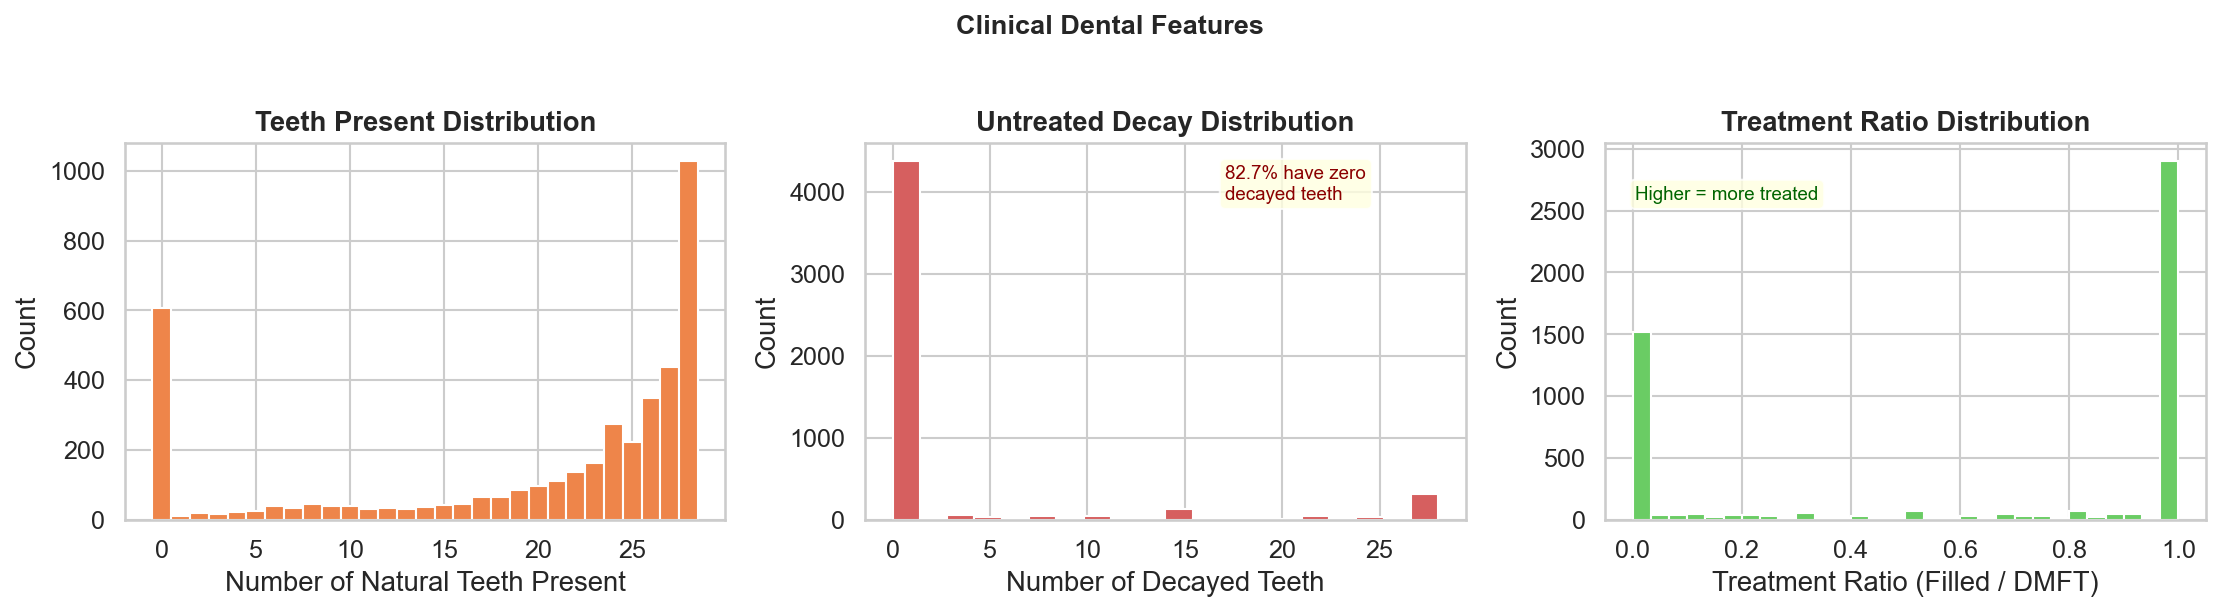

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# teeth present
ax = axes[0]  # First subplot for number of natural teeth present

# plot histogram of teeth present
# use bins from 0 to 28
ax.hist(df['teeth_present'].dropna(), bins=29, range=(-0.5, 28.5),
        color=PALETTE[1], edgecolor='white')

ax.set_xlabel('Number of Natural Teeth Present')
ax.set_ylabel('Count')
ax.set_title('Teeth Present Distribution', fontweight='bold')

# teeth decayed
ax = axes[1]

# plot histogram of decayed teeth counts after removing missing values
ax.hist(df['teeth_decayed'].dropna(), bins=20, color=PALETTE[3], edgecolor='white')

ax.set_xlabel('Number of Decayed Teeth')
ax.set_ylabel('Count')
ax.set_title('Untreated Decay Distribution', fontweight='bold')

# find the proportion of the full sample with no decayed teeth
pct_zero = (df['teeth_decayed'] == 0).mean()

# add a callout box highlighting the share with zero untreated decay
ax.text(0.6, 0.85, f'{pct_zero:.1%} have zero\ndecayed teeth',
        transform=ax.transAxes, fontsize=9, color='darkred',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

# treatment ratio
ax = axes[2]
tr = df['treatment_ratio'].dropna()

# plot histogram of treatment ratio values
ax.hist(tr, bins=30, color=PALETTE[2], edgecolor='white')

ax.set_xlabel('Treatment Ratio (Filled / DMFT)')
ax.set_ylabel('Count')
ax.set_title('Treatment Ratio Distribution', fontweight='bold')

# add a note abotu the meaning of higher vs lower treatment ratio values
ax.text(0.05, 0.85, 'Higher = more treated',
        transform=ax.transAxes, fontsize=9, color='darkgreen',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

plt.suptitle('Clinical Dental Features', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
savefig('fig10_clinical_features.png')
plt.show()